# NLP Metamer Demo: DistilBERT Bypass
This demo demonstrates how to generate NLP metamers by optimizing continuous embeddings instead of discrete tokens. We use DistilBERT fine-tuned on SST-2 as our target model.

In [1]:
import torch
import torch.nn as nn
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import os
import sys

# Add parent directory to path to import metamer_finder
root_dir = os.path.abspath("..")
if root_dir not in sys.path: sys.path.append(root_dir)

from metamer_finder import FeatureExtractor, MetamerOptimizer, get_device

device = get_device()
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

print(f"Loading model: {model_name}...")
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name).to(device).eval()

# Extract the vocabulary matrix
word_embeddings = model.distilbert.embeddings.word_embeddings.weight.data
vocab_size, embedding_dim = word_embeddings.shape
print(f"Vocab size: {vocab_size}, Embedding dim: {embedding_dim}")

W0508 01:44:59.800000 24368 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Loading model: distilbert-base-uncased-finetuned-sst-2-english...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Vocab size: 30522, Embedding dim: 768


## The Forward Pass Override
To allow gradient-based optimization, we wrap the model to accept `inputs_embeds` directly.

In [2]:
class DistilBertBypass(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.model = original_model
        
    def forward(self, inputs_embeds):
        # Pass the optimized embeddings directly to the model
        outputs = self.model(inputs_embeds=inputs_embeds)
        return outputs.logits

bypass_model = DistilBertBypass(model)
print("✅ Bypass model initialized.")

✅ Bypass model initialized.


## Step 2: The "Snap to English" Function (Nearest Neighbor)
We need a way to map our continuous optimized embeddings back to discrete tokens in the DistilBERT vocabulary.

In [9]:
def snap_to_english(optimized_embeds, vocab_matrix, tokenizer):
    """
    Maps continuous embeddings back to the nearest discrete tokens in the vocabulary.
    
    Args:
        optimized_embeds (torch.Tensor): Tensor of shape (seq_len, embedding_dim)
        vocab_matrix (torch.Tensor): The model's embedding matrix (vocab_size, embedding_dim)
        tokenizer: The DistilBertTokenizer
        
    Returns:
        str: The decoded string of nearest-neighbor tokens.
        List[int]: The list of nearest token IDs.
    """
    # 1. Normalize both for cosine similarity
    # normalized_embeds: (seq_len, dim)
    # normalized_vocab: (vocab_size, dim)
    norm_opt = optimized_embeds / (optimized_embeds.norm(dim=-1, keepdim=True) + 1e-8)
    norm_vocab = vocab_matrix / (vocab_matrix.norm(dim=-1, keepdim=True) + 1e-8)
    
    # 2. Compute similarity: (seq_len, dim) @ (dim, vocab_size) -> (seq_len, vocab_size)
    cos_sim = torch.matmul(norm_opt, norm_vocab.t())
    
    # 3. Find indices of maximum similarity
    token_ids = torch.argmax(cos_sim, dim=-1).tolist()
    
    # 4. Decode tokens to text
    decoded_text = tokenizer.decode(token_ids)
    
    return decoded_text, token_ids

print("✅ 'Snap to English' function defined.")

✅ 'Snap to English' function defined.


## Step 3: Demo A — The Standard NLP Metamer
We generate a sequence of embeddings that is mathematically distant from our target sentence but produces the same high-confidence positive sentiment prediction.

In [6]:
target_text = "The user interface is brilliantly designed."
inputs = tokenizer(target_text, return_tensors="pt").to(device)
seq_len = inputs.input_ids.shape[1]

with torch.no_grad():
    # Get target embeddings and logits
    target_embeds = model.distilbert.embeddings(inputs.input_ids)
    target_logits = model(inputs_embeds=target_embeds).logits
    target_probs = torch.softmax(target_logits, dim=-1)

print(f"Target Sentence: '{target_text}'")
print(f"Target Logits: {target_logits.tolist()}")
print(f"Target Confidence (Positive): {target_probs[0, 1].item():.4f}")

# --- Define the Loss Hook ---
def standard_nlp_metamer_loss(synthetic_embeds, current_features, target_features):
    """
    1. Maximize distance from target embeddings (Orthogonality/Uniqueness).
    2. Minimize MSE between synthetic logits and target logits.
    """
    # current_features contains the output of the bypass_model (logits)
    synthetic_logits = current_features["logits"]
    
    # Logit matching loss
    logit_loss = torch.mean((synthetic_logits - target_logits)**2)
    
    # Uniqueness loss: Negative MSE with target embeddings (to push away)
    # We want large distance, so we penalize small distance.
    dist_to_orig = torch.mean((synthetic_embeds - target_embeds)**2)
    uniqueness_loss = 1.0 / (dist_to_orig + 1e-6) * 0.1
    
    return logit_loss + uniqueness_loss

# --- Setup Optimization ---
# We target the 'logits' by wrapping the bypass model in a FeatureExtractor
# Since the bypass model returns logits directly, we can name it 'logits'
class LogitExtractor(nn.Module):
    def __init__(self, bypass):
        super().__init__()
        self.bypass = bypass
    def forward(self, x):
        return {"logits": self.bypass(x)}

extractor = LogitExtractor(bypass_model)
optimizer = MetamerOptimizer(
    extractor=extractor,
    target_features={"logits": target_logits},
    lr=0.05,
    max_iterations=1000,
    custom_loss_hook=standard_nlp_metamer_loss,
    override_base_loss=True # We use our custom loss exclusively
)

starting_noise = torch.randn_like(target_embeds) * 0.02

print("\nGenerating NLP Metamer...")
optimized_embeds = optimizer.generate(starting_image=starting_noise)

# --- The Reveal ---
alien_text, token_ids = snap_to_english(optimized_embeds[0], word_embeddings, tokenizer)

with torch.no_grad():
    # 1. Prediction for CONTINUOUS optimized embeddings
    final_logits = bypass_model(optimized_embeds)
    final_probs = torch.softmax(final_logits, dim=-1)
    
    # 2. Prediction for DISCRETE snapped tokens (The Verification)
    # We tokenize the decoded text normally to see if the sentiment holds
    verify_inputs = tokenizer(alien_text, return_tensors="pt").to(device)
    verify_logits = model(**verify_inputs).logits
    verify_probs = torch.softmax(verify_logits, dim=-1)

print(f"\nFINAL REVEAL:")
print(f"Alien Text: '{alien_text}'")
print(f"[Continuous] Prediction (Positive): {final_probs[0, 1].item():.4f}")
print(f"[Discrete Verified] Prediction (Positive): {verify_probs[0, 1].item():.4f}")

Target Sentence: 'The user interface is brilliantly designed.'
Target Logits: [[-4.180077075958252, 4.462098121643066]]
Target Confidence (Positive): 0.9998

Generating NLP Metamer...


Optimizing (mse): 100%|██████████| 1000/1000 [00:52<00:00, 18.93it/s, loss=0.110360]



FINAL REVEAL:
Alien Text: '& haven townships )mont ijured township within a'
[Continuous] Prediction (Positive): 0.9998
[Discrete Verified] Prediction (Positive): 0.9479


## Step 4: Demo B — The Trojan Injection (The "I Hate This" Bypass)
We freeze a negative statement and optimize three trailing tokens to force the model into a Positive classification.

In [48]:
trojan_text = "i absolutely hate this [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]"
inputs_trojan = tokenizer(trojan_text, return_tensors="pt").to(device)
seq_len_trojan = inputs_trojan.input_ids.shape[1]

with torch.no_grad():
    # Initial embeddings for the trojan template
    trojan_embeds = model.distilbert.embeddings(inputs_trojan.input_ids)

print(f"Trojan Template: '{trojan_text}'")
print(f"Original tokens: {tokenizer.convert_ids_to_tokens(inputs_trojan.input_ids[0])}")

# --- Define the Gradient Mask ---
# Freeze everything except the 3 [MASK] tokens
# [CLS] i absolutely hate this [MASK] [MASK] [MASK] [SEP]
# Indices (likely): 0, 1, 2, 3, 4, 5, 6, 7, 8
mask = torch.zeros((1, seq_len_trojan, 1)).to(device)
for i, token_id in enumerate(inputs_trojan.input_ids[0]):
    if tokenizer.convert_ids_to_tokens(token_id.item()) == "[MASK]":
        mask[0, i, 0] = 1.0
        print(f"Enabling gradient for token at index {i} ('[MASK]')")

# Target: Pure Positive sentiment
positive_target_logits = torch.tensor([[-2.0, 2.0]]).to(device) 

# 1. Identify the Special Tokens to Ban
# In DistilBERT: PAD=0, UNK=100, CLS=101, SEP=102, MASK=103
banned_ids = [0, 100, 101, 102, 103]
vocab_size = model.distilbert.embeddings.word_embeddings.weight.shape[0]

# Create a penalty vector (adds massive distance to banned tokens)
vocab_penalty = torch.zeros(vocab_size, device=device)
vocab_penalty[banned_ids] = 1e9  # Push them infinitely far away
vocab_embeddings = model.distilbert.embeddings.word_embeddings.weight.detach()

snap_probs = []
best_text = (None, 0)
def trojan_injection_loss(synthetic_embeds, current_features, target_features):
    global best_text
    synthetic_logits = current_features["logits"]
    intent_loss = torch.mean((synthetic_logits - positive_target_logits)**2)
    
    synth_flat = synthetic_embeds.squeeze(0) 
    
    # Calculate distances to all dictionary words
    distances = torch.cdist(synth_flat, vocab_embeddings, p=2.0)
    
    # THE FIX: Apply the bouncer penalty to special tokens
    distances = distances + vocab_penalty.unsqueeze(0)
    
    min_distances, _ = torch.min(distances, dim=1) 
    mask_flat = mask.squeeze(0).squeeze(-1) 
    
    quantization_loss = torch.sum(min_distances * mask_flat) / (torch.sum(mask_flat) + 1e-9)
    
    # Keep alpha strong to force it to snap cleanly
    alpha = 5.0 
    
    text = snap_to_english(synthetic_embeds[0], vocab_embeddings, tokenizer)[0]
    inputs = tokenizer(text, return_tensors="pt").to(device)
    logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)
    snap_probs.append(probs[0, 1].item())
    if probs[0, 1].item() > best_text[1]:
        best_text = (text, probs[0, 1].item())
    
    if probs[0, 1].item() > 0.9: return intent_loss - intent_loss
    if probs[0, 1].item() > 0.5: return (intent_loss + (alpha * quantization_loss))*0.1
    
    return (intent_loss + (alpha * quantization_loss))*2

# 2. The Initialization Fix
with torch.no_grad():
    # Start with the trojan template embeddings
    trojan_embeds = model.distilbert.embeddings(inputs_trojan.input_ids).clone()
    
    # Overwrite the [MASK] embeddings with random normal words
    # Let's just pick token IDs around 5000-6000 (standard English words)
    for i, token_id in enumerate(inputs_trojan.input_ids[0]):
        if tokenizer.convert_ids_to_tokens(token_id.item()) == "[MASK]":
            random_word_id = torch.randint(5000, 6000, (1,)).item()
            trojan_embeds[0, i] = model.distilbert.embeddings.word_embeddings.weight[random_word_id]

# Make sure to require gradients again!
trojan_embeds.requires_grad_(True)

# --- Setup Optimization ---
optimizer_trojan = MetamerOptimizer(
    extractor=extractor,
    target_features={"logits": positive_target_logits},
    lr=0.1,
    max_iterations=200,
    custom_loss_hook=trojan_injection_loss,
    override_base_loss=True
)

print("\nInjecting Trojan...")
optimized_trojan_embeds = optimizer_trojan.generate(
    starting_image=trojan_embeds, 
    mask=mask
)

# --- The Reveal ---
final_text, _ = snap_to_english(optimized_trojan_embeds[0], word_embeddings, tokenizer)

with torch.no_grad():
    # 1. Prediction for CONTINUOUS optimized embeddings
    final_logits_trojan = bypass_model(optimized_trojan_embeds)
    final_probs_trojan = torch.softmax(final_logits_trojan, dim=-1)
    
    # 2. Prediction for DISCRETE snapped tokens (The Verification)
    verify_inputs_trojan = tokenizer(final_text, return_tensors="pt").to(device)
    verify_logits_trojan = model(**verify_inputs_trojan).logits
    verify_probs_trojan = torch.softmax(verify_logits_trojan, dim=-1)

if verify_probs_trojan[0, 1].item() > best_text[1]:
     print("\n[!] The final trojan injection outperformed the original metamer!")
     print(f"Original Best Text: '{best_text[0]}' with confidence {best_text[1]:.4f}")
     print(f"Trojan Text: '{final_text}' with confidence {verify_probs_trojan[0, 1].item():.4f}")
else:
     print("\n[✓] An earlier found metamer holds the title for highest confidence!")
     print(f"Best Original Text: '{best_text[0]}' with confidence {best_text[1]:.4f}")
     print(f"Trojan Text: '{final_text}' with confidence {verify_probs_trojan[0, 1].item():.4f}")


Trojan Template: 'i absolutely hate this [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]'
Original tokens: ['[CLS]', 'i', 'absolutely', 'hate', 'this', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[SEP]']
Enabling gradient for token at index 5 ('[MASK]')
Enabling gradient for token at index 6 ('[MASK]')
Enabling gradient for token at index 7 ('[MASK]')
Enabling gradient for token at index 8 ('[MASK]')
Enabling gradient for token at index 9 ('[MASK]')
Enabling gradient for token at index 10 ('[MASK]')
Enabling gradient for token at index 11 ('[MASK]')
Enabling gradient for token at index 12 ('[MASK]')
Enabling gradient for token at index 13 ('[MASK]')
Enabling gradient for token at index 14 ('[MASK]')
Enabling gradient for token at index 15 ('[MASK]')
Enabling gradient for token at index 16 ('[MASK]')

Injecting Trojan...


Optimizing (mse): 100%|██████████| 200/200 [00:20<00:00,  9.81it/s, loss=0.000000]


[✓] An earlier found metamer holds the title for highest confidence!
Best Original Text: '[CLS] i absolutely hate this heart ceased· sexuality quinlan celebration laughed portrait intelligencenally power streamed [SEP]' with confidence 0.9958
Trojan Text: '[CLS] i absolutely hate this heart hearts· sexuality quinlan celebration laughed portrait intelligencenally power streamed [SEP]' with confidence 0.9943


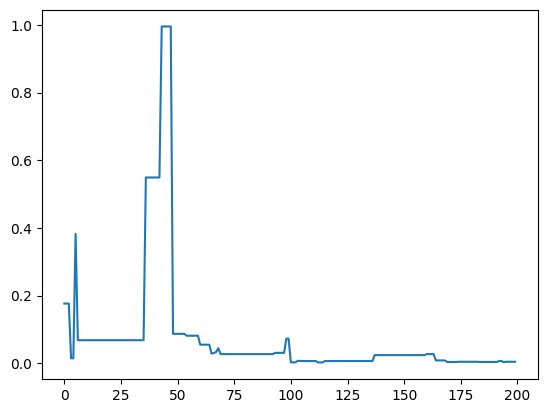

In [44]:
plt.plot(snap_probs)

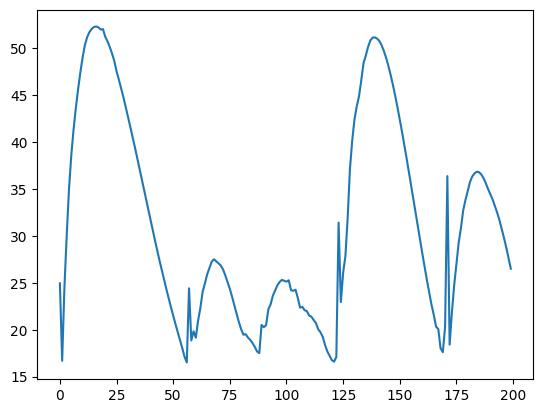

In [40]:
import matplotlib.pyplot as plt
plt.plot(optimizer_trojan.loss_history)
